# پیش‌بینی رکود اقتصادی با Random Forest

داده: شاخص‌های اقتصادی آمریکا (S&P500، منحنی بازده اوراق خزانه، Composite Leading Indicator) به‌صورت ماهانه از ۱۹۶۳ تا ۲۰۱۲ - شامل ۷ دوره رکود.

چون رکود یه رویداد کم‌تکرار (rare event) هست (~۱۵٪ ماه‌ها)، فقط از accuracy استفاده نمی‌کنیم و معیارهای precision/recall/F1/ROC-AUC رو هم چک می‌کنیم.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)

## ۱. بارگذاری و ادغام داده

In [2]:
ind = pd.read_csv('leading_indicators.csv')
rec = pd.read_csv('recession_state.csv')

ind['Date'] = pd.to_datetime(ind['Date'], format='%d-%m-%Y')
rec['Date'] = pd.to_datetime(rec['Date'], format='%d-%m-%Y')

df = pd.merge(ind, rec, on='Date').sort_values('Date').reset_index(drop=True)
df.columns = [c.strip() for c in df.columns]
print('Shape:', df.shape)
print('نرخ رکود در داده:', df['Recession State'].mean().round(3))
df.head()

Shape: (589, 12)
نرخ رکود در داده: 0.153


,Date,SP500 (Percent change from a year ago),10Y Rate - 3M TBill,10Y Rate (Percent change from a year ago,3M TBill (Percent Change from a year ago),3M TBill - FF,6M TBill - FF,1Y Rate - FF,5Y Rate - FF,10Y Rate - FF,Composite Leading Indicator,Recession State
0,1963-01-01,-0.058057,0.92,-6.12745,6.98529,-0.01,0.04,0.15,0.69,0.94,99.9314,0
1,1963-02-01,-0.061236,1.00,-3.69458,6.95971,-0.08,-0.02,0.01,0.66,0.92,100.0743,0
2,1963-03-01,-0.065728,1.04,-0.25381,6.25000,-0.09,-0.03,0.05,0.71,0.95,100.1901,0
3,1963-04-01,0.010434,1.07,3.38542,6.22711,0.00,0.08,0.25,0.87,1.10,100.2720,0
4,1963-05-01,0.113510,1.00,1.55039,8.92193,-0.07,0.01,0.12,0.72,0.93,100.3078,0


## ۲. Feature Engineering

شاخص‌های اقتصادی معمولاً چند ماه *قبل* از رکود سیگنال میدن، پس برای هر فیچر لگ‌های ۱، ۳، ۶ و ۱۲ ماهه و میانگین متحرک ۳ ماهه می‌سازیم.

In [3]:
feature_cols = [c for c in df.columns if c not in ['Date', 'Recession State']]

for col in feature_cols:
    for lag in [1, 3, 6, 12]:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)
    df[f'{col}_roll3'] = df[col].rolling(3).mean()

df = df.dropna().reset_index(drop=True)
print('Shape after feature engineering:', df.shape)

X = df.drop(columns=['Date', 'Recession State'])
y = df['Recession State']

Shape after feature engineering: (577, 62)


## ۳. تقسیم Train/Test (زمانی)

چون دیتا سری زمانیه، split رندوم غلطه (data leakage). ۲۰٪ آخر رو به‌عنوان test نگه می‌داریم.

In [4]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)} ماه ({y_train.mean():.1%} رکود)')
print(f'Test : {len(X_test)} ماه ({y_test.mean():.1%} رکود)')

Train: 461 ماه (15.4% رکود)
Test : 116 ماه (16.4% رکود)


## ۴. آموزش مدل + جستجوی هایپرپارامتر (با TimeSeriesSplit)

`class_weight='balanced'` برای مقابله با imbalance، و CV زمانی به‌جای k-fold معمولی.

In [5]:
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 3, 5],
}
base_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
grid = GridSearchCV(base_rf, param_grid, cv=tscv, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
print('بهترین پارامترها:', grid.best_params_)

بهترین پارامترها: {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 200}


## ۵. تنظیم آستانه تصمیم‌گیری (Threshold Tuning)

آستانه پیش‌فرض ۰.۵ برای داده imbalance مناسب نیست. با out-of-fold prediction روی train، آستانه‌ای که F1 رو بیشینه می‌کنه پیدا می‌کنیم.

In [6]:
oof_proba = np.full(len(X_train), np.nan)
for tr_idx, val_idx in tscv.split(X_train):
    m = RandomForestClassifier(class_weight='balanced', random_state=42, **grid.best_params_)
    m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_proba[val_idx] = m.predict_proba(X_train.iloc[val_idx])[:, 1]
mask = ~np.isnan(oof_proba)
oof_proba, oof_y = oof_proba[mask], y_train.values[mask]

best_thr, best_f1 = 0.5, -1
for thr in np.arange(0.1, 0.9, 0.02):
    f1_ = f1_score(oof_y, (oof_proba >= thr).astype(int), zero_division=0)
    if f1_ > best_f1:
        best_f1, best_thr = f1_, thr
print(f'آستانه بهینه: {best_thr:.2f}')

آستانه بهینه: 0.28


## ۶. ارزیابی روی Test set

In [7]:
y_proba = best_rf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= best_thr).astype(int)

print('Accuracy :', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred, zero_division=0), 3))
print('Recall   :', round(recall_score(y_test, y_pred, zero_division=0), 3))
print('F1-score :', round(f1_score(y_test, y_pred, zero_division=0), 3))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 3))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\n', classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.879
Precision: 1.0
Recall   : 0.263
F1-score : 0.417
ROC-AUC  : 0.971

Confusion Matrix:
 [[97  0]
 [14  5]]

               precision    recall  f1-score   support

           0       0.87      1.00      0.93        97
           1       1.00      0.26      0.42        19

    accuracy                           0.88       116
   macro avg       0.94      0.63      0.67       116
weighted avg       0.89      0.88      0.85       116



## ۷. اهمیت فیچرها

In [8]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

Composite Leading Indicator                     0.108563
Composite Leading Indicator_roll3               0.100139
Composite Leading Indicator_lag1                0.074674
SP500 (Percent change from a year ago)_roll3    0.062435
6M TBill - FF_lag6                              0.060065
SP500 (Percent change from a year ago)          0.054031
1Y Rate - FF_lag6                               0.051549
10Y Rate - FF_lag6                              0.034552
5Y Rate - FF_lag6                               0.031302
6M TBill - FF_lag3                              0.030405
dtype: float64

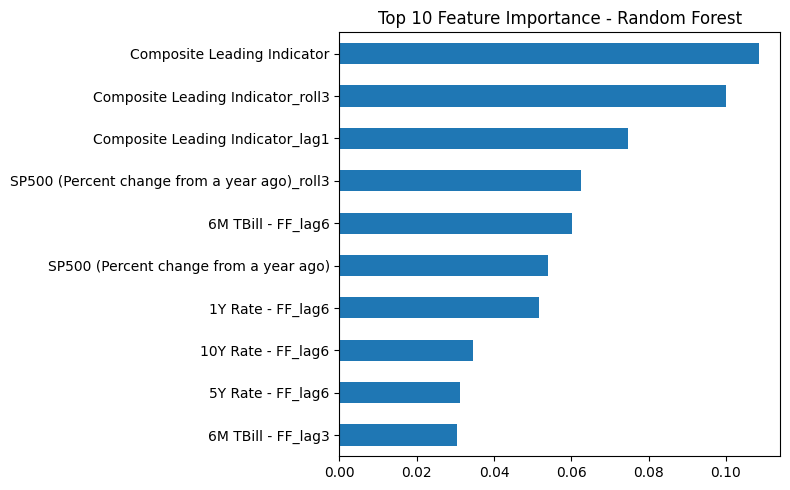

In [9]:
import matplotlib.pyplot as plt
importances.head(10).sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()